In [1]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import quool
import numpy as np
import pandas as pd

In [2]:
qtm = quool.PanelTable("/home/data/quotes-min")
qtd = quool.PanelTable("/home/data/quotes-day")

In [3]:
# 600362.XSHG 江西铜业, 600519.XSHG 贵州茅台， 600570.XSHG 恒生电子
df = qtd.read("close", code='600519.XSHG', start="20180101", stop="20240201").droplevel(0)
df = df['close']
df

date
2018-01-02     703.849976
2018-01-03     715.859985
2018-01-04     737.070007
2018-01-05     738.359985
2018-01-08     752.130005
                 ...     
2024-01-26    1637.319946
2024-01-29    1650.000000
2024-01-30    1613.000000
2024-01-31    1604.910034
2024-02-01    1610.030029
Name: close, Length: 1480, dtype: float32

<Axes: xlabel='date'>

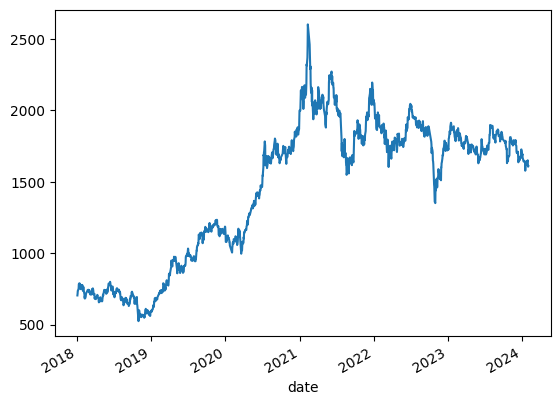

In [4]:
df.plot()

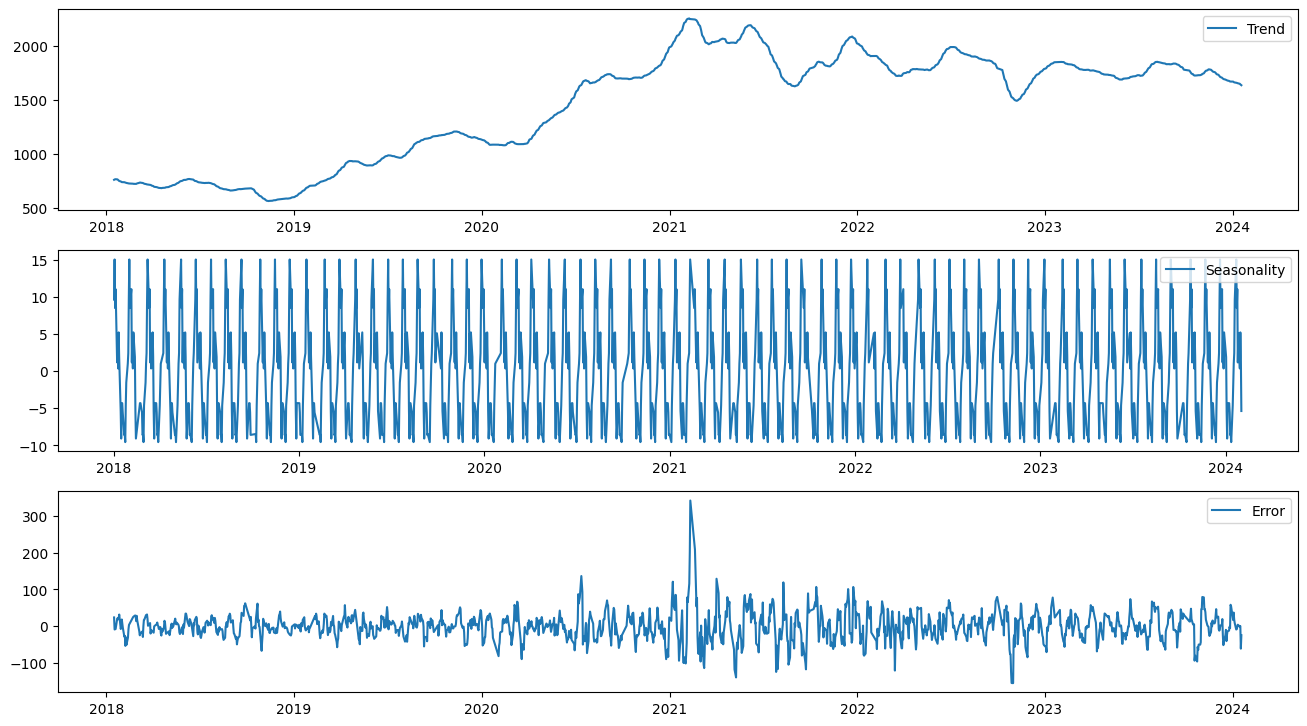

,resid_component
date,
2018-01-16,23.805439
2018-01-17,-8.869563
2018-01-18,-8.045919
2018-01-19,-7.509684
2018-01-22,19.932750
...,...
2024-01-12,2.950401
2024-01-15,-1.478898
2024-01-16,0.247876


In [5]:
def decomposing(time_series):
    # 如果季节性随着时间的增长而增加，则可能需要使用乘法模型（model='multiplicative'）来进行分解。
    # 白噪声是一种理想化的随机过程，具有恒定的均值和方差，并且各个时间点之间完全独立，没有自相关性。
    decompostition = seasonal_decompose(time_series, model='additive', period=21)
    trend =  decompostition.trend
    seasonal = decompostition.seasonal
    random = decompostition.resid
    
    plt.figure(figsize=(16,12))
    plt.subplot(412)
    plt.plot(trend, label='Trend')
    plt.legend(loc = 'best')
    plt.subplot(413)
    plt.plot(seasonal, label='Seasonality')
    plt.legend(loc = 'best')
    plt.subplot(414)
    plt.plot(random, label='Error')
    plt.legend(loc = 'best')
    plt.show()
    return trend,seasonal,random

def to_frame(data):
    df = pd.DataFrame(data)
    df = df.dropna()
    df.columns = ['{}_component'.format(data.name)]
    return df

trendComponent,seasonalComponent,randomComponent = decomposing(df)
trendComponent = to_frame(trendComponent)
seasonalComponent = to_frame(seasonalComponent)
randomComponent = to_frame(randomComponent)
randomComponent

In [6]:
def adf_test(df):
    result = adfuller(df, autolag='AIC', regression='ctt')  # 包含常数项、线性趋势项和二次趋势项
    print('ADF Statistic for trend and intercept: %f' % result[0])
    print('p-value for trend and intercept: %f' % result[1])
    print("Critical Values:")
    for key, val in result[4].items():
        print("\t", key, ":", val)
    if result[1] > 0.05:
        print("This implies that the time series is non-stationary.")
    else:
        print("This implies that the time series is stationary.")

    result = adfuller(df, autolag='AIC', regression='ct')  # 常数项和线性趋势项
    print('ADF Statistic for trend and intercept: %f' % result[0])
    print('p-value for trend and intercept: %f' % result[1])
    print("Critical Values:")
    for key, val in result[4].items():
        print("\t", key, ":", val)
    if result[1] > 0.05:
        print("This implies that the time series is non-stationary.")
    else:
        print("This implies that the time series is stationary.")
    
    result = adfuller(df, autolag='AIC', regression='c')  # 常数项 认为股价没有明确的线性趋势，但可能围绕某个平均水平波动
    print('ADF Statistic for intercept: %f' % result[0])
    print('p-value for intercept: %f' % result[1])
    print("Critical Values:")
    for key, val in result[4].items():
        print("\t", key, ":", val)    
    if result[1] > 0.05:
        print("This implies that the time series is non-stationary.")
    else:
        print("This implies that the time series is stationary.")
    
    result = adfuller(df, autolag='AIC', regression='n')  # 全无
    print('ADF Statistic for none: %f' % result[0])
    print("Critical Values:")
    for key, val in result[4].items():
        print("\t", key, ":", val)
    print('p-value for none: %f' % result[1])
    if result[1] > 0.05:
        print("This implies that the time series is non-stationary.")
    else:
        print("This implies that the time series is stationary.")

adf_test(df)

ADF Statistic for trend and intercept: -3.114118
p-value for trend and intercept: 0.243752
Critical Values:
	 1% : -4.379051411038981
	 5% : -3.836424293873901
	 10% : -3.5557587995079873
This implies that the time series is non-stationary.
ADF Statistic for trend and intercept: -1.376903
p-value for trend and intercept: 0.867566
Critical Values:
	 1% : -3.9649586452686143
	 5% : -3.413489034667975
	 10% : -3.1288155441792176
This implies that the time series is non-stationary.
ADF Statistic for intercept: -1.519386
p-value for intercept: 0.523901
Critical Values:
	 1% : -3.4348184769200056
	 5% : -2.86351353803652
	 10% : -2.567820693109295
This implies that the time series is non-stationary.
ADF Statistic for none: 0.276106
Critical Values:
	 1% : -2.5672667899584765
	 5% : -1.9411847754662341
	 10% : -1.6166400815103692
p-value for none: 0.768336
This implies that the time series is non-stationary.


In [14]:
dftest = adfuller(df, autolag = 'AIC') # 默认使用仅常数项
print("1. ADF:", dftest[0])  # 越小（越负）意味着时间序列越可能是平稳的。
print("2. P-Value:", dftest[1])
print("3. Num of Lags:", dftest[2])
print("4. Num of Observations Used For ADF Regression and Critical Values Calculation:", dftest[3])
print("5. Critical Values:")
for key, val in dftest[4].items():
    print("\t", key, ":", val)

if dftest[1] > 0.05:
    print("This implies that the time series is non-stationary.")
else:
    print("This implies that the time series is stationary.")


# KPSS检验 和ADF相反，p-value越小越不稳定，备择假设（H1）是时间序列是非平稳的。
kpss_result = kpss(df)
print('KPSS Statistic: %f' % kpss_result[0])
print('p-value: %f' % kpss_result[1])
if kpss_result[1] < 0.05:
    print("KPSS Test: The time series is non-stationary.")
else:
    print("KPSS Test: The time series is stationary.")

1. ADF: -1.519385848404564
2. P-Value: 0.5239005725100598
3. Num of Lags: 13
4. Num of Observations Used For ADF Regression and Critical Values Calculation: 1466
5. Critical Values:
	 1% : -3.4348184769200056
	 5% : -2.86351353803652
	 10% : -2.567820693109295
This implies that the time series is non-stationary.
KPSS Statistic: 4.390614
p-value: 0.010000
KPSS Test: The time series is non-stationary.


/tmp/ipykernel_3691692/3480539796.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df)


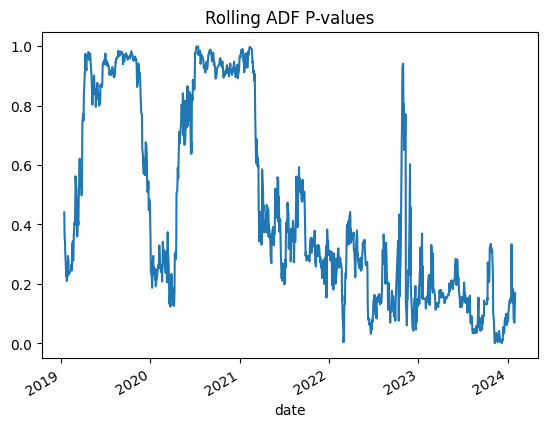

In [9]:
def rolling_adf(df, window):
    adf_results = df.rolling(window=window).apply(lambda x: adfuller(x)[1], raw=False)
    return adf_results

rolling_adf_results = rolling_adf(df, 252)
rolling_adf_results.plot(title="Rolling ADF P-values")
plt.show()

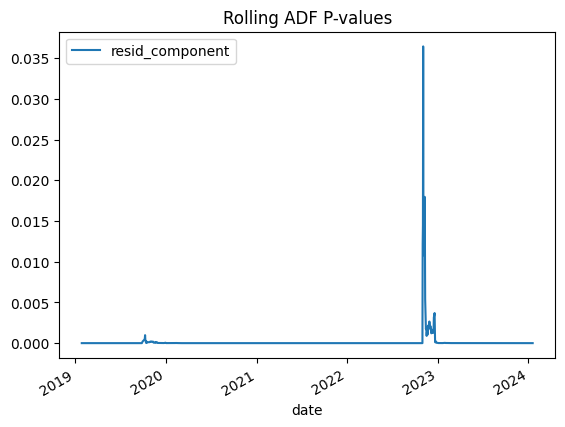

In [10]:
def rolling_adf(df, window):
    adf_results = df.rolling(window=window).apply(lambda x: adfuller(x, regression='ct')[1], raw=False)
    return adf_results

rolling_adf_results = rolling_adf(randomComponent, 252)
rolling_adf_results.plot(title="Rolling ADF P-values")
plt.show()

In [26]:
# 将前后序列拆分成2个序列，分别计算这2个序列的均值，方差，对比看是否差异明显。
def describe(X): 
    split = int(len(X) / 2)
    X1, X2 = X[0:split], X[split:]
    mean1, mean2 = X1.mean(), X2.mean()
    var1, var2 = X1.var(), X2.var()
    print('mean1=%f, mean2=%f' % (mean1, mean2))
    print('variance1=%f, variance2=%f' % (var1, var2))

print('random walk sample')
describe(df)

random walk sample
mean1=57.280960, mean2=62.642666
variance1=518.924744, variance2=675.360840


## 建模

In [20]:
df = qtd.read("close", code='600570.XSHG', start="20140424", stop="20240424").droplevel(0)    #恒生电子
df2 = df['close'].diff()
df = df['close']
df2 = df2.dropna()
df2

date
2014-04-25   -0.710001
2014-04-28   -2.680000
2014-04-29    0.500000
2014-04-30    0.900000
2014-05-05    1.080000
                ...   
2024-04-18   -0.040001
2024-04-19   -0.680000
2024-04-22    0.260000
2024-04-23   -0.020000
2024-04-24    0.230001
Name: close, Length: 2433, dtype: float32

In [22]:
dftest = adfuller(df, autolag = 'AIC')
print("1. ADF:", dftest[0])
print("2. P-Value:", dftest[1])
print("3. Num of Lags:", dftest[2])
print("4. Num of Observations Used For ADF Regression and Critical Values Calculation:", dftest[3])
print("5. Critical Values:")
for key, val in dftest[4].items():
    print("\t", key, ":", val)

if dftest[1] > 0.05:
    print("This implies that the time series is non-stationary.")
else:
    print("This implies that the time series is stationary.")

dftest = adfuller(df2, autolag = 'AIC')
print("1. ADF:", dftest[0])
print("2. P-Value:", dftest[1])
print("3. Num of Lags:", dftest[2])
print("4. Num of Observations Used For ADF Regression and Critical Values Calculation:", dftest[3])
print("5. Critical Values:")
for key, val in dftest[4].items():
    print("\t", key, ":", val)

if dftest[1] > 0.05:
    print("This implies that the time series is non-stationary.")
else:
    print("This implies that the time series is stationary.")

1. ADF: -2.541679433954767
2. P-Value: 0.10565972491649761
3. Num of Lags: 11
4. Num of Observations Used For ADF Regression and Critical Values Calculation: 2422
5. Critical Values:
	 1% : -3.4330528258368695
	 5% : -2.862734077195586
	 10% : -2.5674056563936007
This implies that the time series is non-stationary.
1. ADF: -14.894964689017941
2. P-Value: 1.5372417802635067e-27
3. Num of Lags: 10
4. Num of Observations Used For ADF Regression and Critical Values Calculation: 2422
5. Critical Values:
	 1% : -3.4330528258368695
	 5% : -2.862734077195586
	 10% : -2.5674056563936007
This implies that the time series is stationary.


<Figure size 1400x700 with 0 Axes>

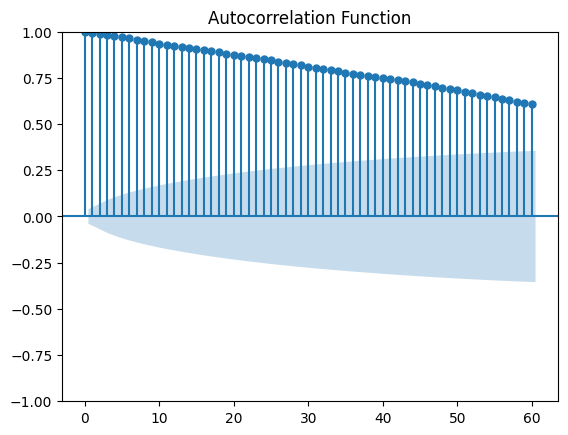

<Figure size 1400x700 with 0 Axes>

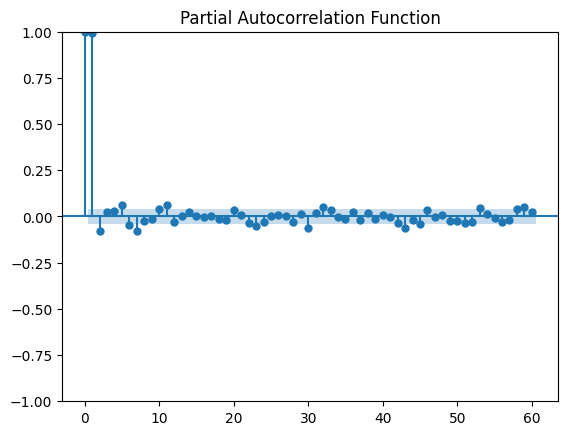

<Figure size 1400x700 with 0 Axes>

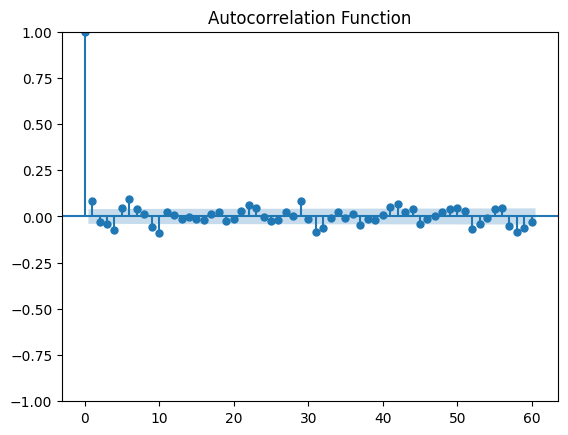

<Figure size 1400x700 with 0 Axes>

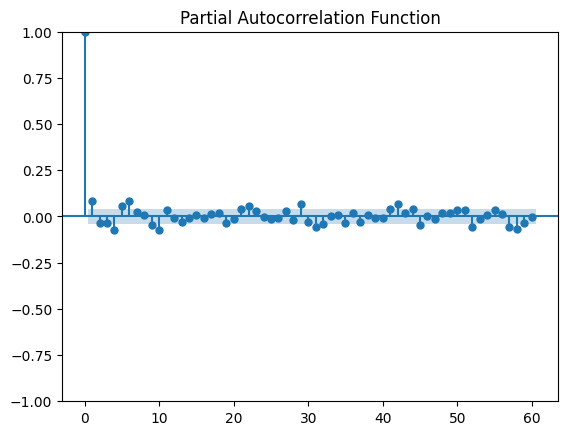

In [24]:
# Sample ACF
plt.figure(figsize=(14, 7))
plot_acf(df, lags=60, alpha=0.05) 
plt.title('Autocorrelation Function')
plt.show()

# Sample PACF
plt.figure(figsize=(14, 7))
plot_pacf(df, lags=60, alpha=0.05) 
plt.title('Partial Autocorrelation Function')
plt.show()

# Sample ACF
plt.figure(figsize=(14, 7))
plot_acf(df2, lags=60, alpha=0.05) 
plt.title('Autocorrelation Function')
plt.show()

# Sample PACF
plt.figure(figsize=(14, 7))
plot_pacf(df2, lags=60, alpha=0.05) 
plt.title('Partial Autocorrelation Function')
plt.show()
# q - 移动平均项的阶数，可以从 ACF 图中找到显著的滞后数。
# p - 自回归项的阶数，可以从 PACF 图中找到显著的滞后数。
# d - 差分次数，使得数据成为平稳序列。

# ACF 自相关性，和多少天的数据相关，间隔k
# PACF 剔除中间k-1个随机变量，观察X(t-k)对X(t)影响的相关程度
# 股价的自相关系数下降缓慢可能表明存在一定的趋势性或周期性
# 股价的PACF只和前一项相关

# 白噪声resid：IID（Independent Identically Distributed 独立同分布）的话，PACF和ACF图都是除了与自身的相关性为1，其他滞后的自相关性都是接近于零的.
# 随机游走 X(t)=X(t−1)+ϵ(t)

/home/wiikai/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/wiikai/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/wiikai/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/wiikai/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/wiik

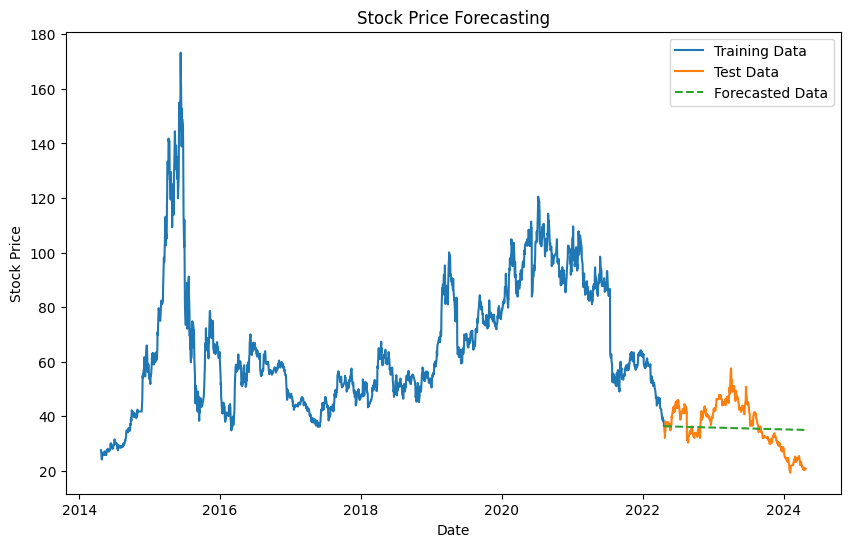

In [102]:
n = len(df)
train_data = df[:int(n*0.8)]
test_data = df[int(n*0.8):]

model = ARIMA(df2, order=(1, 0, 1)) 
model_fit = model.fit()

diff_forecast = model_fit.forecast(steps=len(test_data))

# 将差分预测结果转换为原始数据
last_train_value = train_data.iloc[-1]
original_forecast = last_train_value + diff_forecast.cumsum()

# 使用测试集的日期索引来标记预测结果
forecast_series = pd.Series(data=original_forecast.values, index=test_data.index)

plt.figure(figsize=(10, 6))
plt.plot(train_data, label='Training Data')
plt.plot(test_data, label='Test Data')
plt.plot(forecast_series, label='Forecasted Data', linestyle='--')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Forecasting')
plt.show()

In [109]:
# n = len(df)
# train = df[:int(n*0.8)]
# test = df[int(n*0.8):]

# model = ARIMA(train, order=(2, 2, 22))  #p,d,q
# fitted_model = model.fit()

# forecast = fitted_model.get_forecast(steps=len(test))
# mean_forecast = forecast.predicted_mean
# conf_int = forecast.conf_int()

# plt.figure(figsize=(10, 5))
# plt.plot(df.index, df, label='Observed', color='blue')
# plt.plot(test.index, mean_forecast, label='Forecast', color='red')
# plt.title('ARIMA Forecast')
# plt.xlabel('Date')
# plt.ylabel('Values')
# plt.legend()
# plt.show()

## 分钟线分析

In [111]:
df3 = qtm.read("close", code='600570.XSHG', start="20240101", stop="20240424").droplevel(0)  
df3 = df3['close']
df3

datetime
2024-01-02 09:31:00    28.809999
2024-01-02 09:32:00    28.809999
2024-01-02 09:33:00    28.799999
2024-01-02 09:34:00    28.590000
2024-01-02 09:35:00    28.590000
                         ...    
2024-04-23 14:56:00    20.540001
2024-04-23 14:57:00    20.540001
2024-04-23 14:58:00    20.540001
2024-04-23 14:59:00    20.540001
2024-04-23 15:00:00    20.549999
Name: close, Length: 17520, dtype: float32

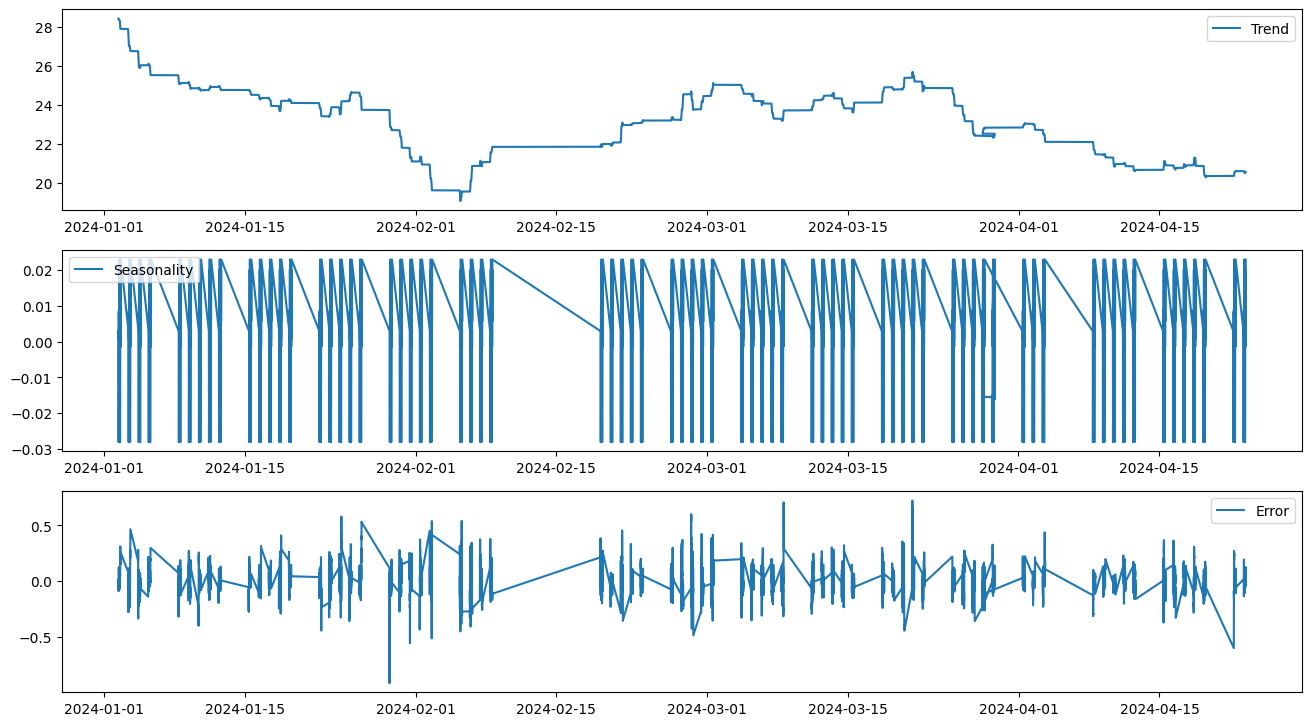

,trend_component
datetime,
2024-01-02 10:31:00,28.424042
2024-01-02 10:32:00,28.420042
2024-01-02 10:33:00,28.416292
2024-01-02 10:34:00,28.413417
2024-01-02 10:35:00,28.411583
...,...
2024-04-23 13:56:00,20.547208
2024-04-23 13:57:00,20.547792
2024-04-23 13:58:00,20.548292


In [114]:
def decomposing(time_series):
    decompostition = seasonal_decompose(time_series, model='additive', period=120)
    trend =  decompostition.trend
    seasonal = decompostition.seasonal
    random = decompostition.resid
    
    plt.figure(figsize=(16,12))
    plt.subplot(412)
    plt.plot(trend, label='Trend')
    plt.legend(loc = 'best')
    plt.subplot(413)
    plt.plot(seasonal, label='Seasonality')
    plt.legend(loc = 'best')
    plt.subplot(414)
    plt.plot(random, label='Error')
    plt.legend(loc = 'best')
    plt.show()
    return trend,seasonal,random

def to_frame(data):
    df = pd.DataFrame(data)
    df = df.dropna()
    df.columns = ['{}_component'.format(data.name)]
    return df

trendComponent,seasonalComponent,randomComponent = decomposing(df3)
randomComponent = to_frame(randomComponent)
seasonalComponent = to_frame(seasonalComponent)
trendComponent = to_frame(trendComponent)
trendComponent

In [117]:
adf_test(df3)

ADF Statistic for trend and intercept: -2.428719
p-value for trend and intercept: 0.609753
Critical Values:
	 1% : -4.371791694794424
	 5% : -3.832727201041783
	 10% : -3.553468946242751
This implies that the time series is non-stationary.
ADF Statistic for trend and intercept: -2.460949
p-value for trend and intercept: 0.347753
Critical Values:
	 1% : -3.9592869401353354
	 5% : -3.410740680293394
	 10% : -3.1271976264075008
This implies that the time series is non-stationary.
ADF Statistic for intercept: -2.572710
p-value for intercept: 0.098770
Critical Values:
	 1% : -3.4307233876788485
	 5% : -2.8617050229420165
	 10% : -2.5668578374267907
This implies that the time series is non-stationary.
ADF Statistic for none: -1.779425
Critical Values:
	 1% : -2.5658676551191952
	 5% : -1.9410153455131482
	 10% : -1.616804845561851
p-value for none: 0.071422
This implies that the time series is non-stationary.


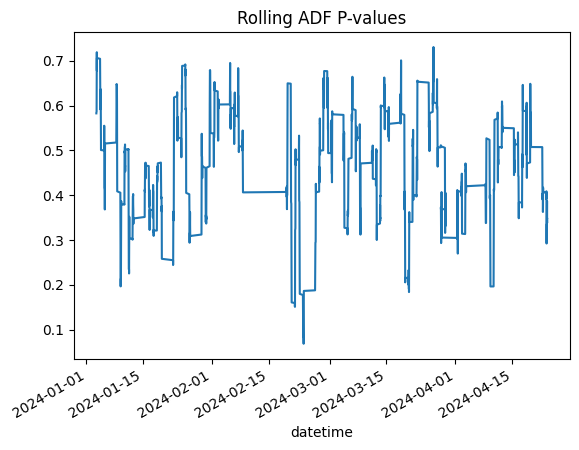

In [116]:
def rolling_adf(series, window):
    adf_results = series.rolling(window=120).apply(lambda x: adfuller(x)[1], raw=False).rolling(window=window).mean()
    return adf_results

rolling_adf_results = rolling_adf(df3, 240)
rolling_adf_results.plot(title="Rolling ADF P-values")
plt.show()